# DBSCAN aplicado a turismo interno

Base real del DANE preparada previamente: **1.399 viajes internos**, descritos por noches de viaje y gasto total en COP.

Ruta de la exposición: datos → distancias → DBSCAN → experimentos con parámetros → configuración de demostración.

# 1. ¿Qué problema resuelve DBSCAN?

DBSCAN es un algoritmo de **clustering no supervisado**: recibe observaciones sin etiquetas y busca grupos de puntos cercanos y densos. No se le indica de antemano cuántos grupos debe producir.

# 2. Conceptos para leer las gráficas

- **Vecindad:** puntos ubicados a una distancia máxima `eps`.
- **Núcleo:** tiene al menos `min_samples` puntos en su vecindad.
- **Frontera:** pertenece a un grupo, pero no alcanza la densidad de núcleo.
- **Ruido:** no queda conectado a una región suficientemente densa, DBSCAN lo etiqueta con `-1`.

Un cluster empieza en un núcleo y se expande conectando núcleos vecinos, los puntos frontera pueden quedar adheridos a esa región.

# 3. Importar librerías

In [11]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({"figure.figsize": (9, 5), "font.size": 12})
pd.set_option("display.float_format", "{:.2f}".format)

# 4. Cargar la base preparada

La preparación anterior ya filtró turismo interno, trató los códigos especiales de gasto y exportó las dos columnas seleccionadas.

In [12]:
RUTA_DATOS = Path("datos_procesados/turismo_interno_dbscan.csv")
df = pd.read_csv(RUTA_DATOS)

print(f"Filas y columnas: {df.shape}")
df.head()

Filas y columnas: (1399, 2)


,noches_viaje,gasto_total_cop
0,3,150000.00
1,1,60000.00
2,6,2000000.00
3,4,2000000.00
4,4,2000000.00


In [13]:
df.describe()

,noches_viaje,gasto_total_cop
count,1399.00,1399.00
mean,4.22,1118890.10
std,4.75,1478306.13
min,1.00,50000.00
25%,2.00,255200.00
50%,3.00,550000.00
75%,5.00,1300000.00
max,87.00,10000000.00


# 5. Ver las dos variables antes de agrupar

Cada punto representa un viaje. La escala logarítmica del eje vertical es solo visual: permite observar gastos pequeños y grandes en una misma gráfica.

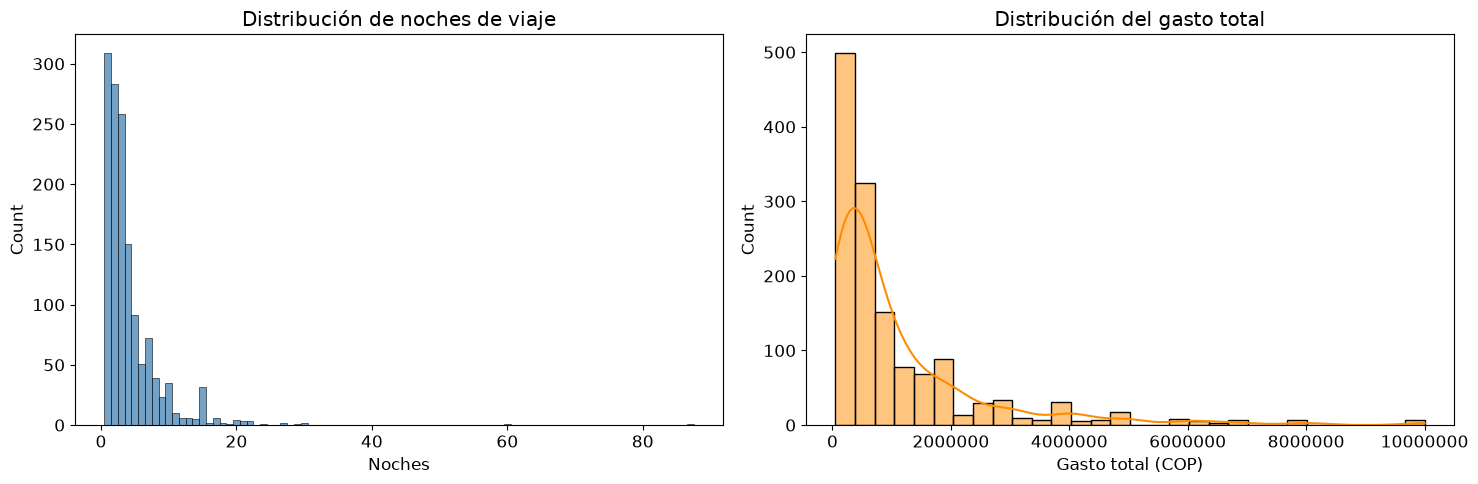

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=df, x="noches_viaje", discrete=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribución de noches de viaje")
axes[0].set_xlabel("Noches")

sns.histplot(data=df, x="gasto_total_cop", bins=30, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribución del gasto total")
axes[1].set_xlabel("Gasto total (COP)")
axes[1].ticklabel_format(style="plain", axis="x")

plt.tight_layout()
plt.show()

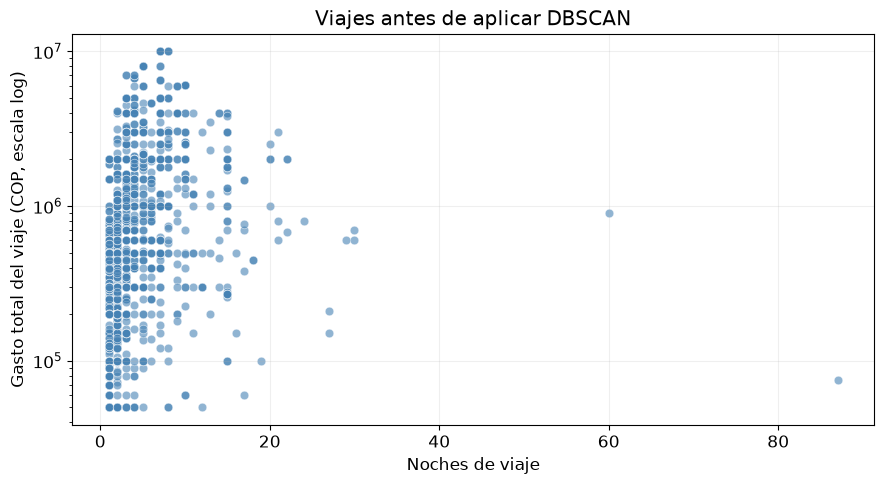

In [15]:
plt.figure()
sns.scatterplot(data=df, x="noches_viaje", y="gasto_total_cop", color="steelblue", s=38, alpha=0.60)
plt.yscale("log")
plt.title("Viajes antes de aplicar DBSCAN")
plt.xlabel("Noches de viaje")
plt.ylabel("Gasto total del viaje (COP, escala log)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 6. Matriz de correlación

Se utilizan `corr()` y `sns.heatmap()` vistos en clase. La tabla calcula la relación lineal, no decide por sí sola si debe existir un cluster.

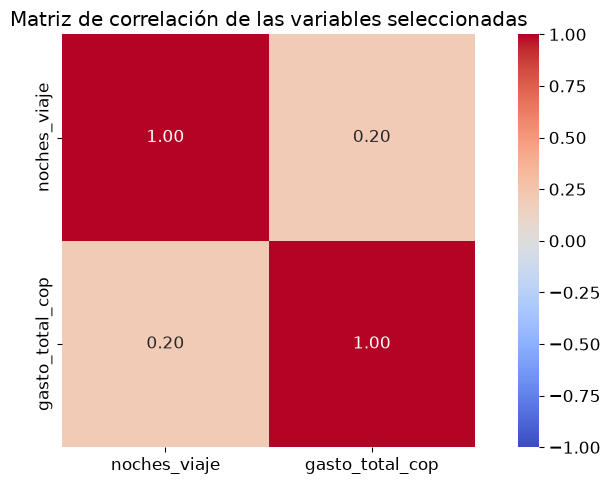

,noches_viaje,gasto_total_cop
noches_viaje,1.00,0.20
gasto_total_cop,0.20,1.00


In [16]:
matriz_correlacion = df.corr()

sns.heatmap(matriz_correlacion, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Matriz de correlación de las variables seleccionadas")
plt.tight_layout()
plt.show()

matriz_correlacion

# 7. Preparar las distancias

DBSCAN usa distancias. Como las variables tienen unidades y asimetrías distintas, se aplica `log1p` para suavizar escalas y `StandardScaler` para que ambas participen en la distancia. La base original no se modifica.

In [17]:
df_modelo = df.copy()
df_modelo[["log_noches", "log_gasto"]] = np.log1p(
    df_modelo[["noches_viaje", "gasto_total_cop"]]
)

escalador = StandardScaler()
X_escalado = escalador.fit_transform(df_modelo[["log_noches", "log_gasto"]])
df_modelo[["noches_escaladas", "gasto_escalado"]] = X_escalado

df_modelo[["noches_viaje", "gasto_total_cop", "noches_escaladas", "gasto_escalado"]].head()

,noches_viaje,gasto_total_cop,noches_escaladas,gasto_escalado
0,3,150000.00,-0.08,-1.15
1,1,60000.00,-1.22,-1.93
2,6,2000000.00,0.84,1.06
3,4,2000000.00,0.29,1.06
4,4,2000000.00,0.29,1.06


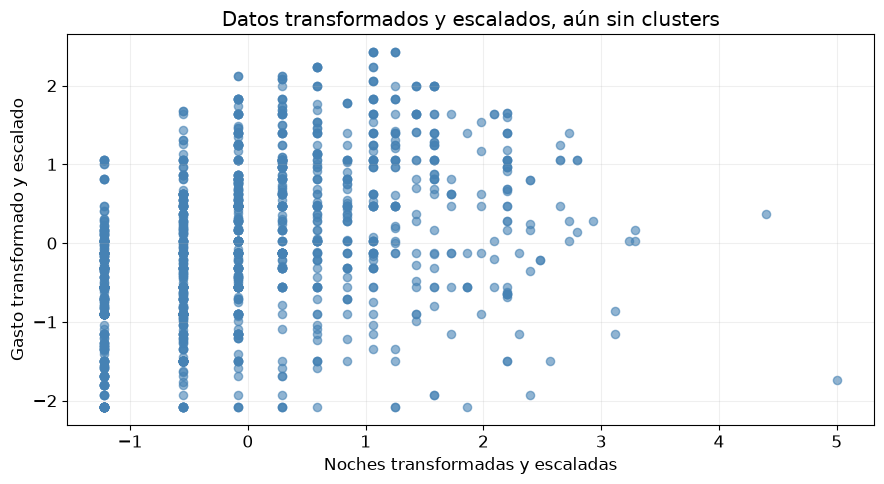

In [18]:
plt.figure()
plt.scatter(X_escalado[:, 0], X_escalado[:, 1], color="steelblue", s=35, alpha=0.60)
plt.title("Datos transformados y escalados, aún sin clusters")
plt.xlabel("Noches transformadas y escaladas")
plt.ylabel("Gasto transformado y escalado")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 8. Criterio previo, gráfico K-distance

Antes de ejecutar DBSCAN se observa la distancia de cada punto a su vecino número `min_samples`. El cambio de pendiente de la curva orienta un valor candidato para `eps`. Para esta demostración se propone `eps=0.30` con `min_samples=8`. La gráfica es una vista ampliada para que el cambio sea visible, no se eliminan datos.

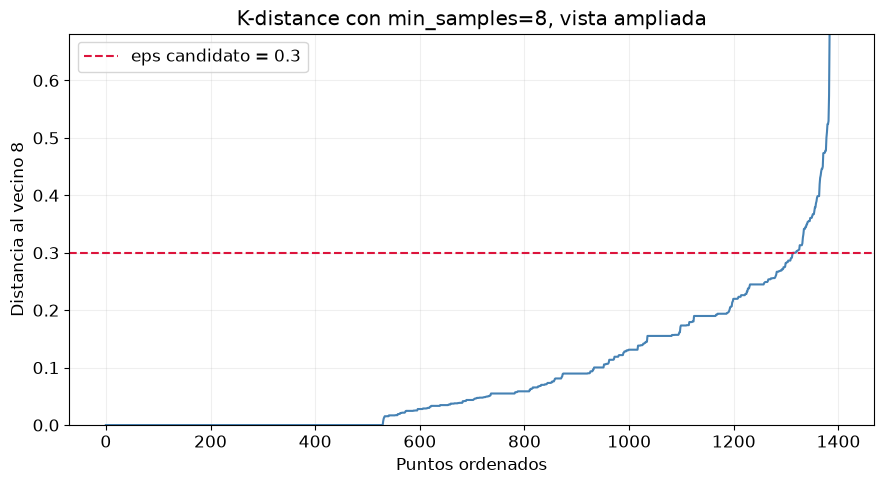

In [19]:
min_samples_kdist = 8
eps_candidato = 0.30

vecinos = NearestNeighbors(n_neighbors=min_samples_kdist)
distancias, _ = vecinos.fit(X_escalado).kneighbors(X_escalado)
k_distances = np.sort(distancias[:, -1])
limite_visual = np.quantile(k_distances, 0.99)

plt.figure()
plt.plot(k_distances, color="steelblue")
plt.axhline(eps_candidato, color="crimson", linestyle="--", label=f"eps candidato = {eps_candidato}")
plt.ylim(0, limite_visual)
plt.title(f"K-distance con min_samples={min_samples_kdist}, vista ampliada")
plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al vecino {min_samples_kdist}")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

COLORES_CLUSTERS = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00"]


def ajustar_dbscan(X, eps, min_samples):
    modelo = DBSCAN(eps=eps, min_samples=min_samples)
    etiquetas = modelo.fit_predict(X)
    return modelo, etiquetas


def resumen_dbscan(etiquetas, eps, min_samples):
    numero_clusters = len(set(etiquetas)) - int(-1 in etiquetas)
    numero_ruido = int((etiquetas == -1).sum())
    return {
        "eps": eps,
        "min_samples": min_samples,
        "clusters": numero_clusters,
        "ruido": numero_ruido,
        "ruido (%)": round(numero_ruido / len(etiquetas) * 100, 2),
    }


def graficar_dbscan(ax, X, etiquetas, titulo):
    for etiqueta in sorted(set(etiquetas)):
        mascara = etiquetas == etiqueta
        nombre = "Ruido (-1)" if etiqueta == -1 else f"Cluster {etiqueta}"
        if etiqueta == -1:
            ax.scatter(X[mascara, 0], X[mascara, 1], s=44, alpha=0.95, color="#1A1A1A", marker="X", label=nombre)
        else:
            color = COLORES_CLUSTERS[etiqueta % len(COLORES_CLUSTERS)]
            ax.scatter(X[mascara, 0], X[mascara, 1], s=26, alpha=0.72, color=color, marker="o", label=nombre)
    ax.set_title(titulo)
    ax.set_xlabel("Noches transformadas y escaladas")
    ax.set_ylabel("Gasto transformado y escalado")
    ax.grid(alpha=0.2)

# 9. Primera ejecución de DBSCAN

El gráfico K-distance propone `eps=0.30` como valor candidato. DBSCAN recibe `eps` y `min_samples`, y con ellos identifica automáticamente la cantidad de clusters. Luego se prueban variaciones de los dos parámetros.

In [20]:
eps_inicial = eps_candidato
min_samples_inicial = 8
modelo_inicial, etiquetas_iniciales = ajustar_dbscan(X_escalado, eps_inicial, min_samples_inicial)

pd.DataFrame([resumen_dbscan(etiquetas_iniciales, eps_inicial, min_samples_inicial)])

,eps,min_samples,clusters,ruido,ruido (%)
0,0.30,8,6,50,3.57


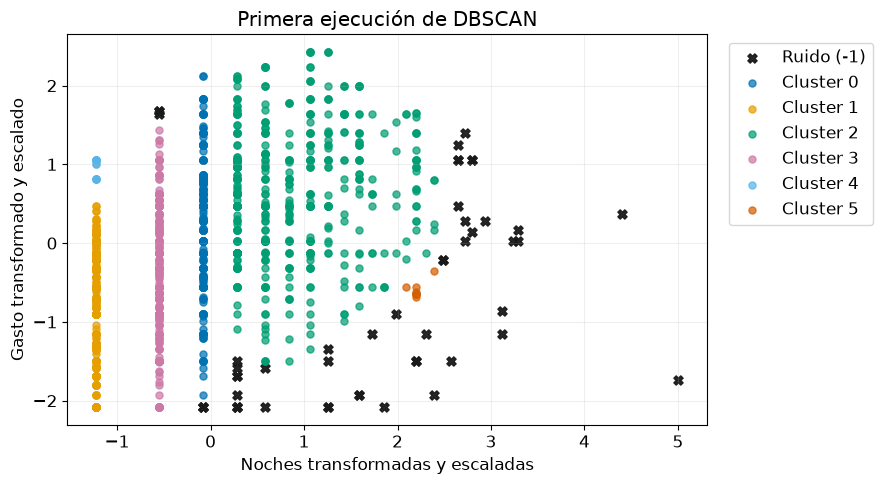

In [21]:
fig, ax = plt.subplots()
graficar_dbscan(ax, X_escalado, etiquetas_iniciales, "Primera ejecución de DBSCAN")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 10. Experimento 1 — Cambiar `eps`

Se mantiene `min_samples` fijo. Un `eps` mayor permite conectar vecindades más lejanas, la lectura se hace comparando las tres gráficas.

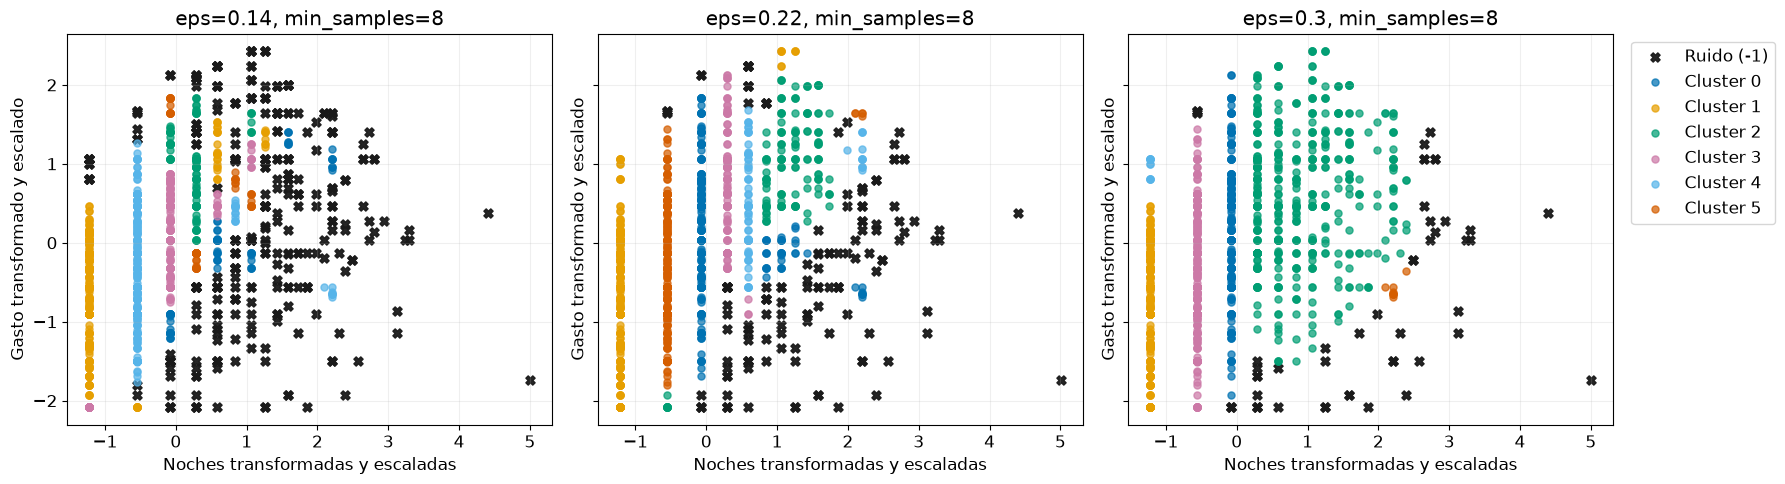

,eps,min_samples,clusters,ruido,ruido (%)
0,0.14,8,26,302,21.59
1,0.22,8,14,137,9.79
2,0.30,8,6,50,3.57


In [22]:
min_samples_fijo = 8
valores_eps = [0.14, 0.22, 0.30]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
resumen_eps = []

for ax, eps in zip(axes, valores_eps):
    _, etiquetas = ajustar_dbscan(X_escalado, eps, min_samples_fijo)
    graficar_dbscan(ax, X_escalado, etiquetas, f"eps={eps}, min_samples={min_samples_fijo}")
    resumen_eps.append(resumen_dbscan(etiquetas, eps, min_samples_fijo))

axes[-1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

pd.DataFrame(resumen_eps)

# 11. Experimento 2 — Cambiar `min_samples`

Se mantiene `eps` fijo. Un `min_samples` mayor exige una región más poblada para considerar núcleo a un punto.

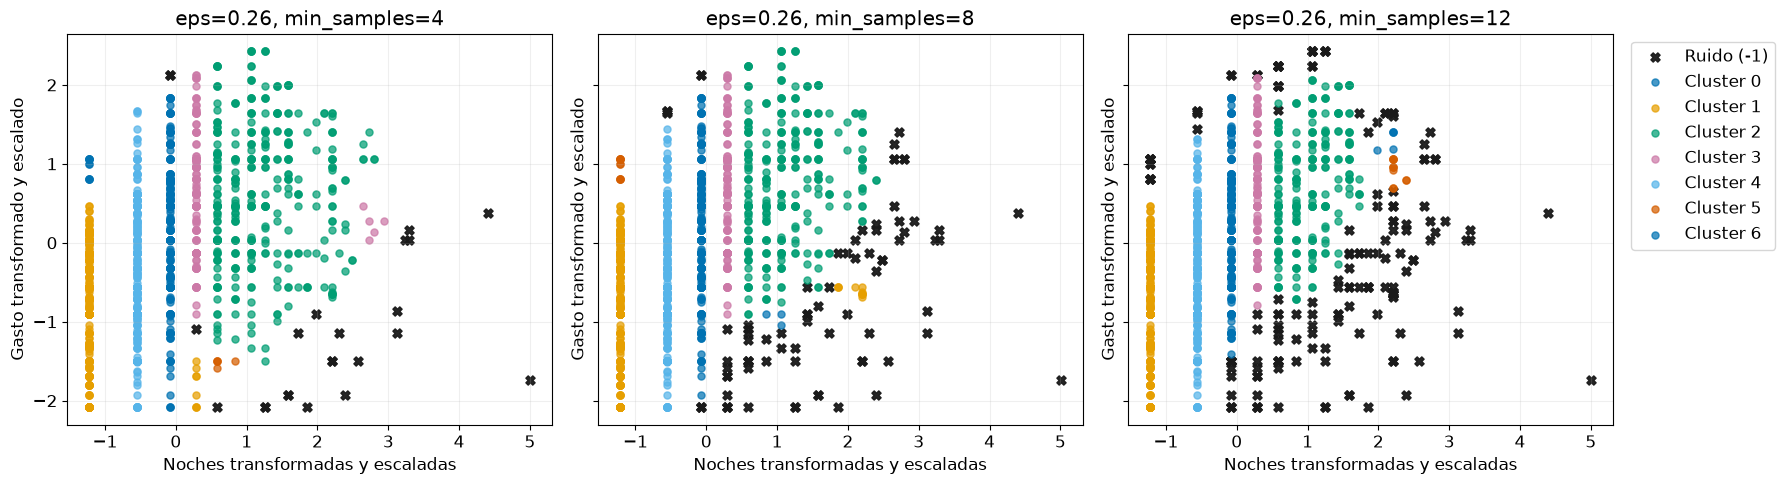

,eps,min_samples,clusters,ruido,ruido (%)
0,0.26,4,10,23,1.64
1,0.26,8,8,79,5.65
2,0.26,12,7,162,11.58


In [23]:
eps_fijo = 0.26
valores_min_samples = [4, 8, 12]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
resumen_min_samples = []

for ax, min_samples in zip(axes, valores_min_samples):
    _, etiquetas = ajustar_dbscan(X_escalado, eps_fijo, min_samples)
    graficar_dbscan(ax, X_escalado, etiquetas, f"eps={eps_fijo}, min_samples={min_samples}")
    resumen_min_samples.append(resumen_dbscan(etiquetas, eps_fijo, min_samples))

axes[-1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

pd.DataFrame(resumen_min_samples)

# 12. Interacción entre los dos parámetros

Los parámetros actúan juntos. La tabla y las cuatro gráficas permiten comparar simultáneamente clusters y ruido.

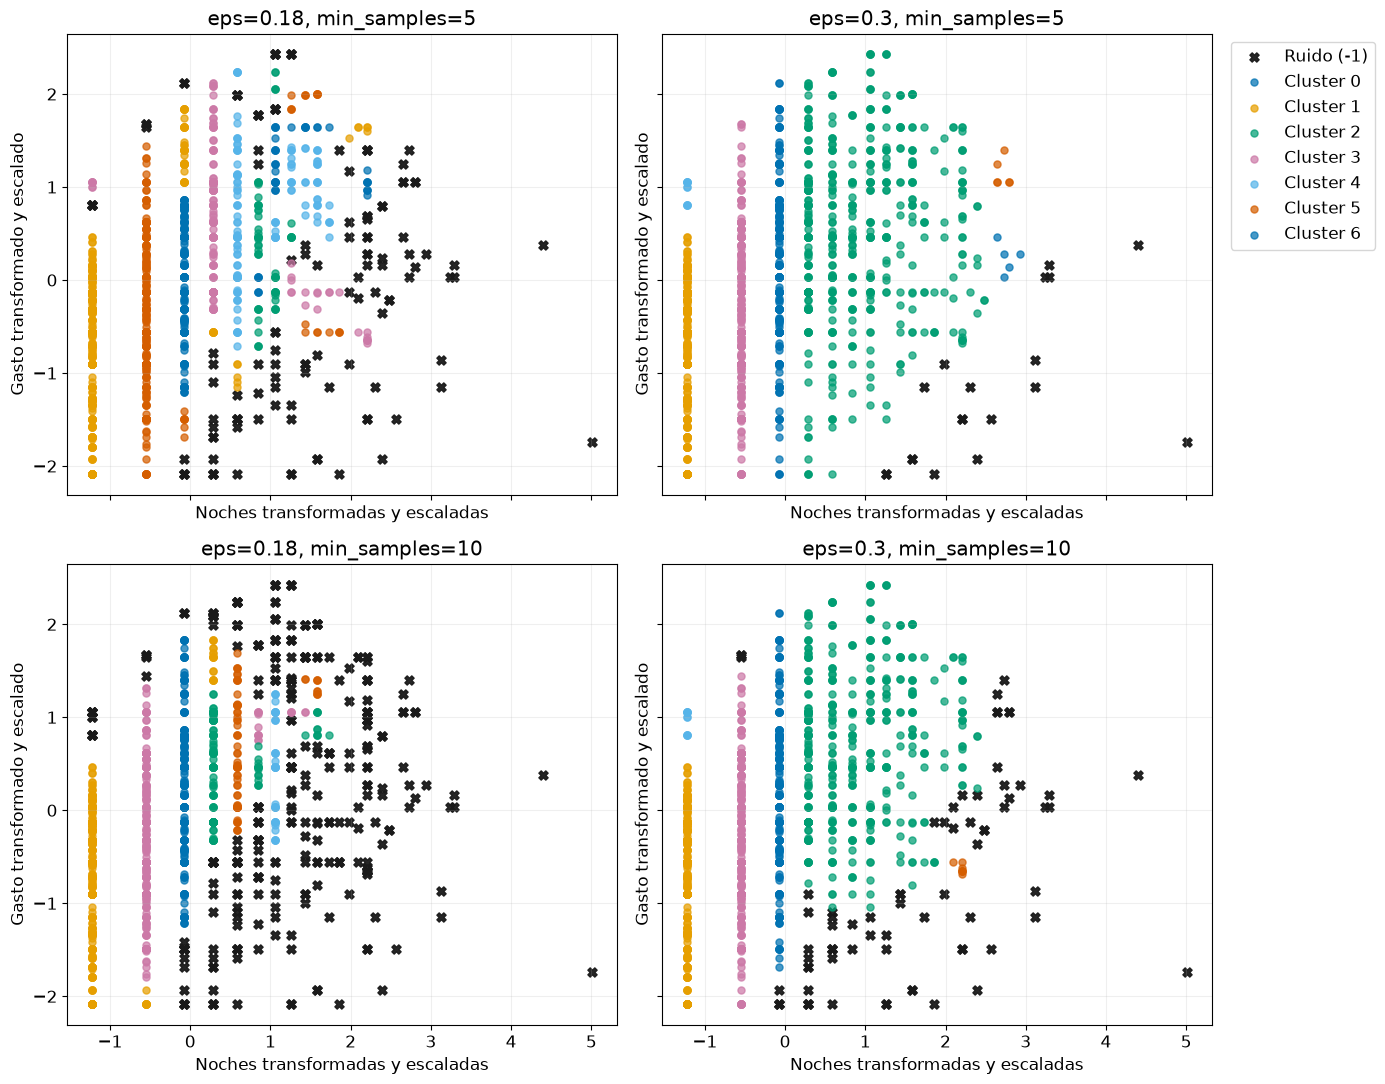

,eps,min_samples,clusters,ruido,ruido (%)
0,0.18,5,27,125,8.93
1,0.30,5,7,19,1.36
2,0.18,10,18,292,20.87
3,0.30,10,6,74,5.29


In [24]:
combinaciones = [(0.18, 5), (0.30, 5), (0.18, 10), (0.30, 10)]
fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharex=True, sharey=True)
resumen_interaccion = []

for ax, (eps, min_samples) in zip(axes.flat, combinaciones):
    _, etiquetas = ajustar_dbscan(X_escalado, eps, min_samples)
    graficar_dbscan(ax, X_escalado, etiquetas, f"eps={eps}, min_samples={min_samples}")
    resumen_interaccion.append(resumen_dbscan(etiquetas, eps, min_samples))

axes[0, 1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

pd.DataFrame(resumen_interaccion)

In [25]:
# El gráfico K-distance se ejecuta antes de los experimentos.

# 13. Configuración de demostración y tipos de punto

Se vuelve a usar `eps=0.30` y `min_samples=8` para cerrar la demostración. La segunda gráfica diferencia núcleo, frontera y ruido, los grupos siguen identificados por sus etiquetas numéricas.

In [26]:
eps_final = 0.30
min_samples_final = 8
modelo_final, etiquetas_finales = ajustar_dbscan(X_escalado, eps_final, min_samples_final)

es_nucleo = np.zeros(len(etiquetas_finales), dtype=bool)
es_nucleo[modelo_final.core_sample_indices_] = True

df_resultado = df_modelo.copy()
df_resultado["cluster"] = etiquetas_finales
df_resultado["tipo_punto"] = np.select(
    [etiquetas_finales == -1, es_nucleo],
    ["Ruido", "Núcleo"],
    default="Frontera",
)

pd.DataFrame([resumen_dbscan(etiquetas_finales, eps_final, min_samples_final)])

,eps,min_samples,clusters,ruido,ruido (%)
0,0.30,8,6,50,3.57


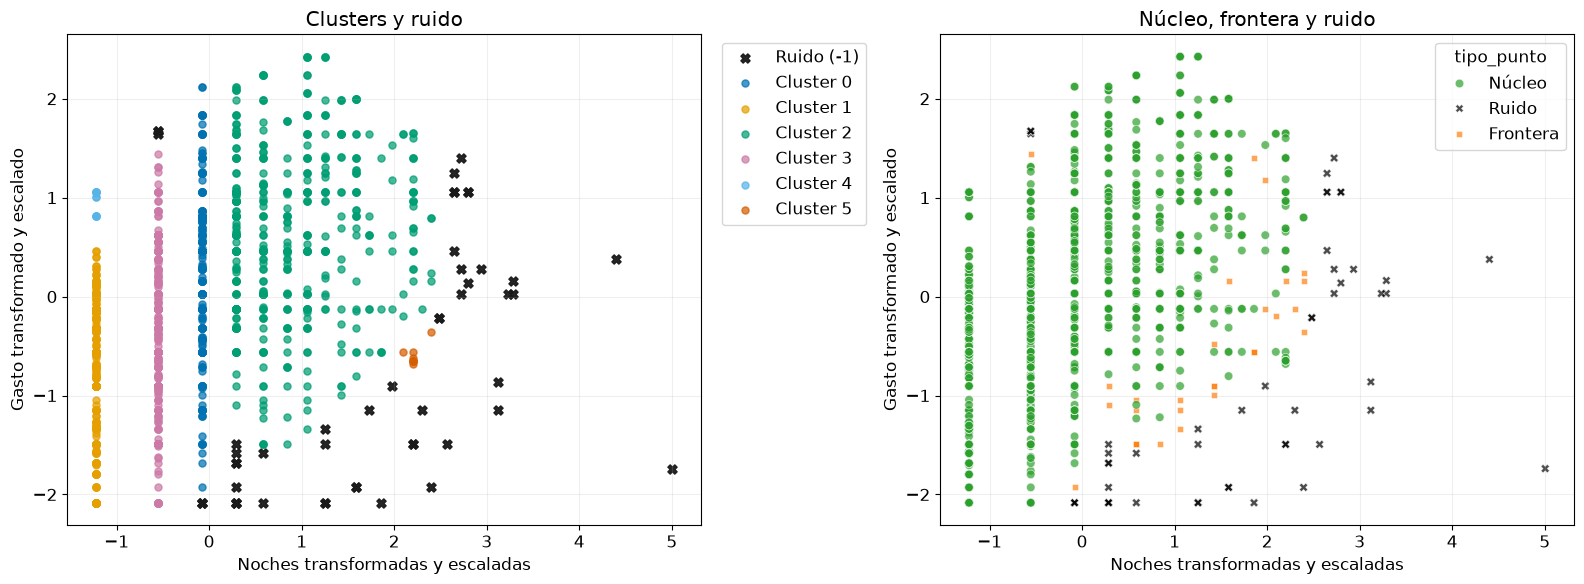

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
graficar_dbscan(axes[0], X_escalado, etiquetas_finales, "Clusters y ruido")
axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left")

sns.scatterplot(
    data=df_resultado, x="noches_escaladas", y="gasto_escalado",
    hue="tipo_punto", style="tipo_punto",
    palette={"Núcleo": "#2ca02c", "Frontera": "#ff7f0e", "Ruido": "black"},
    s=38, alpha=0.70, ax=axes[1]
)
axes[1].set_title("Núcleo, frontera y ruido")
axes[1].set_xlabel("Noches transformadas y escaladas")
axes[1].set_ylabel("Gasto transformado y escalado")
axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [28]:
resumen_clusters = (
    df_resultado.loc[df_resultado["cluster"].ne(-1)]
    .groupby("cluster", as_index=False)
    .agg(
        viajes=("cluster", "size"),
        noches_promedio=("noches_viaje", "mean"),
        gasto_promedio_cop=("gasto_total_cop", "mean"),
    )
    .sort_values("cluster")
)
resumen_clusters.round(2)

,cluster,viajes,noches_promedio,gasto_promedio_cop
0,0,255,3.00,1184035.29
1,1,298,1.00,315907.38
2,2,496,6.75,1932706.45
3,3,280,2.00,543930.18
4,4,11,1.00,1796363.64
5,5,9,15.11,288888.89


# 14. ¿Cuándo usar DBSCAN y cuándo no?

**Útil** cuando se esperan regiones densas, formas no necesariamente circulares y se quiere identificar ruido.

**Cuidado** cuando hay densidades muy diferentes, muchas dimensiones o no existe una separación de densidad clara.

A diferencia de K-Means, DBSCAN no exige definir `K` ni calcula centroides. Sus resultados dependen de las distancias y de los dos parámetros explorados.

## Referencias de apoyo

- [Tutorial DBSCAN de apoyo](https://medium.com/latinxinai/tutorial-del-algoritmo-dbscan-en-python-d7c187c1b24f)
- [Documentación de DBSCAN en scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html)